In [289]:
import sys
sys.path.append('../modules')

#from spike_train import generate_spike_train

#Optional Test: Generates spike trains oustide of HH Model, but I might remove this part later
#spikes = generate_spike_train(duration_ms=1000, rate_hz=20)
#print("Spike times (ms):", spikes)

In [290]:
from parameters import(
    NUM_NEURONS, TIME_WINDOW_MS, DT_MS, HH_PARAMS,
    CONNECTION_PROB, MIN_DELAY_MS, MAX_DELAY_MS,
    INHIBITORY_RATIO, HEALTHY_RATE_RANGE, AD_RATE_RANGE
)

from connectivity import generate_connectivity_matrix 
from synaptic_delay import generate_synaptic_delays 
from neuron_types import assign_neuron_types   
#from firing_rate import calculate_firing_rate 
from hh_model import build_hh_neuron_group 
from visualization import plot_population_spike_trains

from brian2 import SpikeMonitor, StateMonitor, run, ms, mV, nA

import numpy as np
import matplotlib.pyplot as plt

In [291]:
#Implemented*************
#from brian2 import nA 

CONDITION = "healthy"

if CONDITION == "AD":
    HH_PARAMS['I'] = 2.0 * nA 
else:
    HH_PARAMS['I'] = 3.0 * nA

In [292]:
#Building Network

#Building neuron group using Hodgkin Huxley model
neurons = build_hh_neuron_group(NUM_NEURONS, HH_PARAMS)

#Generate network structure
connectivity = generate_connectivity_matrix(NUM_NEURONS, CONNECTION_PROB)
delays = generate_synaptic_delays(connectivity, MIN_DELAY_MS, MAX_DELAY_MS)
types = assign_neuron_types(NUM_NEURONS, INHIBITORY_RATIO)

In [ ]:
#Integrating connectivity, delays, and neuron types

from brian2 import Synapses, ms, mV, volt
import numpy as np

#Creating synapses using connectivity + delays + neuron types
#Each presynaptic spike adds w to the postsynaptic membrane potential
syn = Synapses(
    neurons,
    neurons,
    model='''
         w : volt    #synaptic weight
    ''',
    on_pre='''
       v_post += w      #postsynaptic weight
    '''
)

#Connecting neurons according to connectivity matrix
#Creates a synapse for every "1" in connectivity matrix
i_indices, j_indices = np.where(connectivity == 1)
syn.connect(i=i_indices, j=j_indices)

#Assigning delays
#Brian2 automatically maps delay to the correct synapse
syn.delay = delays[i_indices, j_indices] * ms

if CONDITION == "healthy":
    exc_weight = 0.1 * mV
    inh_weight = -0.2 * mV

elif CONDITION == "AD":
    #AD weakens synapses
    exc_weight = 0.05 * mV
    inh_weight = -0.1 * mV

weight = [exc_weight if types[i] == 1 else inh_weight for i in i_indices]
syn.w = weight

In [294]:
#Simulate Spike Trains
#I dont think this is needed lol we already did it above? from brian2 import SpikeMonitor, StateMonitor, run, ms, mV??????

#Attaching monitors
spike_monitor = SpikeMonitor (neurons)
voltage_monitor = StateMonitor(neurons, 'v', record=True)

#Run Simulation
run(TIME_WINDOW_MS * ms)

In [295]:
#Tests spike trains generation outside of Brian2
#I might remove this later if it proves to be redundant

#import numpy as np 
#time_steps = int(TIME_WINDOW_MS / DT_MS)
#healthy_rates = np.random.uniform(*HEALTHY_RATE_RANGE, NUM_NEURONS)
#prob_per_ms = healthy_rates / 1000.0 # Hz to spikes/ms
#healthy_spikes = np.random.rand(NUM_NEURONS, time_steps) < prob_per_ms[:, None]

In [ ]:
spikes_per_neuron = np.bincount(spike_monitor.i, minlength=NUM_NEURONS)
mean_spikes = np.mean(spikes_per_neuron)
print("Mean spikes per neuron:", mean_spikes)

Mean spikes per neuron: 51.132


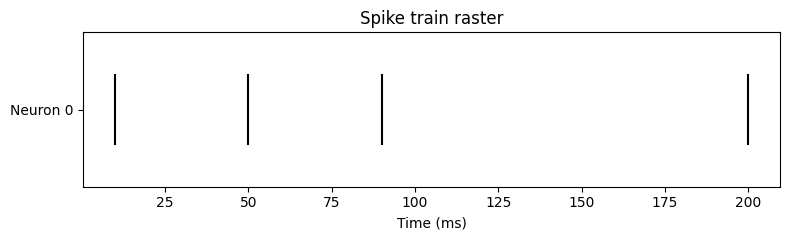

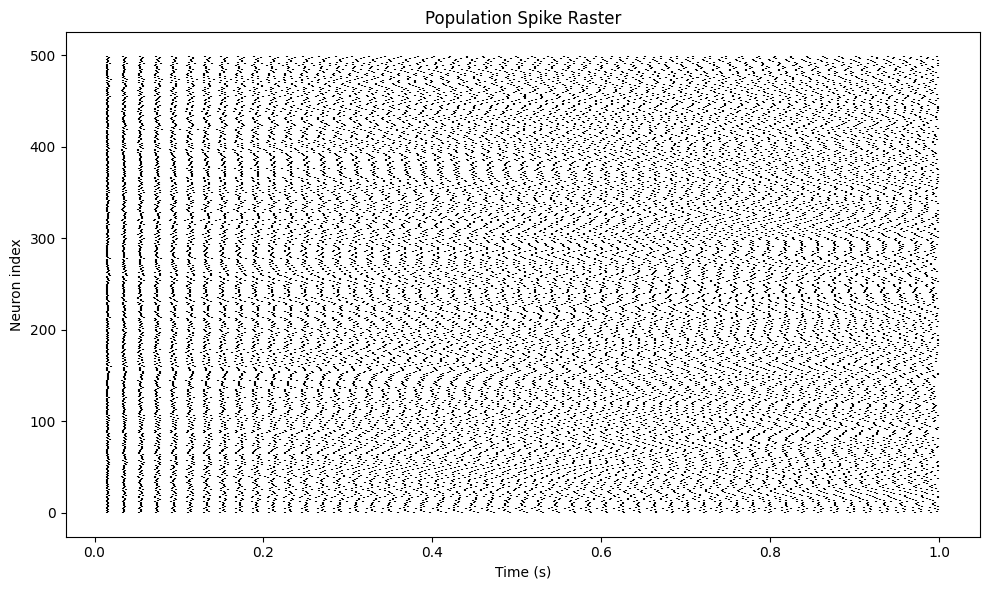

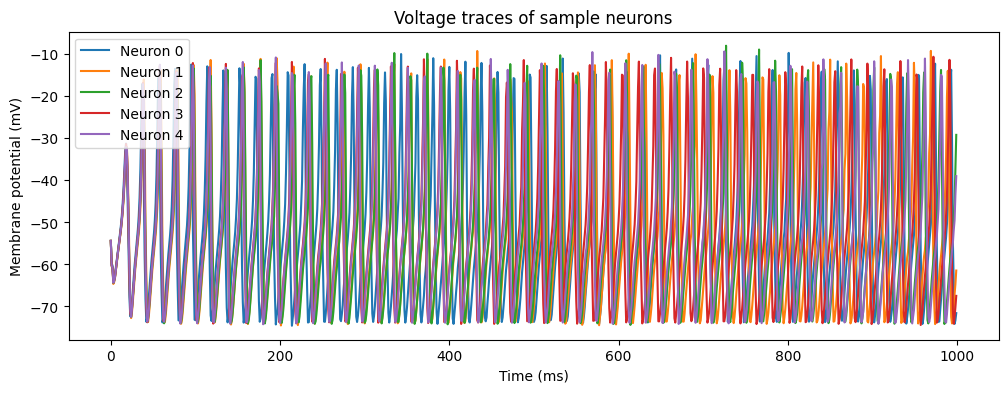

In [297]:
#Might delete plot_spike_train it tests single neuron
#Single neuron test plot
from visualization import plot_spike_train, plot_population_spike_trains 
plot_spike_train([10, 50, 90, 200], neuron_id=0)



#Visualize population spike trains/raster plot
#Shows when neurons are fired
plot_population_spike_trains(spike_monitor)

#Plot voltage traces, it plots the membrane potential over time for a few neurons
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
for i in range(min(5,NUM_NEURONS)):
    plt.plot(voltage_monitor.t / ms, voltage_monitor.v[i] / mV, label=f'Neuron {i}')
plt.xlabel('Time (ms)')
plt.ylabel('Membrane potential (mV)')
plt.title('Voltage traces of sample neurons')
plt.legend()
plt.show()